# パッケージのインストール

In [1]:
# パッケージのインストール
list.of.packages <- c("rTensor", "ggplot2", "reshape2", "RColorBrewer")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)){
    install.packages(new.packages,
        repos="https://cloud.r-project.org/", type="source")
}

# パッケージの読み込み

In [2]:
library("rTensor")
library("ggplot2")
library("reshape2")
library("RColorBrewer")

# 定数の設定

元論文 (Tan et al., Mol Syst Biol, 2021) ではCMTF（CP分解ベース）のランク2を使用し、2成分だけで分散の74%を説明できることを示した。ここではTucker分解（HOSVD）を用いる。

HOSVDはCP分解と異なり、因子行列が直交制約を持ち、コアテンソルを介して成分間の相互作用も表現できるため、因子の解釈が異なる場合がある。

In [3]:
# 元論文 (Tan et al., Mol Syst Biol, 2021) ではCMTF（CP分解ベース）のランク2を使用し、
# 2成分だけで分散の74%を説明できることを示した
# ここではTucker分解（HOSVD）を用いる
# HOSVDはCP分解と異なり、因子行列が直交制約を持ち、コアテンソルを介して成分間の
# 相互作用も表現できるため、因子の解釈が異なる場合がある
J <- 2  # Tucker分解のランク（成分数）
HEATMAP_COLORS <- brewer.pal(11, "PiYG")
HEATMAP_THEME <- theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    text = element_text(size = 30))

# 関数定義

## データの概要

COVID-19患者の血清学的アッセイ（蛍光強度）を測定したデータ (Zohar et al., 2020) を用いる。

- **受容体/抗体** (11種): IgG1, IgG2, IgG3, IgA1, IgA2, IgM, FcRalpha, FcR2A, FcR2B, FcR3A, FcR3B
- **抗原** (6種): S, RBD, N, S1, S2, S1.Trimer（SARS-CoV-2由来タンパク質）
- **検体** (438サンプル): 一人の患者から複数時点で採取されるため、サンプル数 > 患者数

患者の重症度分類: **Negative**(陰性) / **Mild**(軽症) / **Moderate**(中等症) / **Severe**(重症) / **Deceased**(死亡)

このデータを **受容体(11) × 抗原(6) × サンプル(438)** の3階テンソルとして構成し、テンソル分解を適用する。

In [4]:
# Zenodoから血清学データをダウンロードし、3階テンソル（受容体×抗原×検体）に整形する関数
# データ概要:
#   COVID-19患者の血清学的アッセイ（蛍光強度）を測定したデータ
#   - 受容体/抗体 (11種): IgG1, IgG2, IgG3, IgA1, IgA2, IgM, FcRalpha, FcR2A, FcR2B, FcR3A, FcR3B
#   - 抗原 (6種): S, RBD, N, S1, S2, S1.Trimer（SARS-CoV-2由来）
#   - 検体 (438サンプル): 一人の患者から複数時点で採取されるため、サンプル数 > 患者数
#   患者の重症度分類: Negative(陰性), Mild(軽症), Moderate(中等症), Severe(重症), Deceased(死亡)
load_serology <- function(){
    # Download from Zenodo Server
    td <- tempdir()
    tempfile <- paste0(td, "/meyer-lab-systemsSerology-fd9ef61.zip")
    download.file("https://zenodo.org/record/5184449/files/meyer-lab/systemsSerology-v1.0.zip?download=1", tempfile)
    # Preprocessing
    unzip(tempfile, exdir=td)
    csvfile <- paste0(td, "/meyer-lab-systemsSerology-fd9ef61/syserol/data/ZoharCovData.csv")
    data <- read.csv(csvfile, row.names=1, header=TRUE)
    serology <- t(t(as.matrix(data[, 23:140])) - unlist(data[443, 23:140]))
    serology <- serology[1:438, ]
    # Data frame -> Array
    receptor <- c("IgG1", "IgG2", "IgG3", "IgA1", "IgA2", "IgM", "FcRalpha", "FcR2A", "FcR2B", "FcR3A", "FcR3B")
    antigen <- c("S", "RBD", "N", "S1", "S2", "S1.Trimer")
    arr <- array(0, dim=c(11, 6, 438))
    dimnames(arr) <- list(
        receptor = receptor,
        antigen = antigen,
        samples = rownames(serology))
    for(i in receptor){
        for(j in antigen){
            arr[i, j, ] <- serology[, paste0(i, "_", j)]
        }
    }
    # Log Transformation
    arr[which(arr < 0)] <- 10
    arr <- log10(arr)
    # Centering
    for(k in seq_len(dim(arr)[3])){
        arr[,,k] <- arr[,,k] - mean(arr[,,k])
    }
    # Array -> Tensor
    covid19 <- as.tensor(arr)
    # Group Label
    group <- cbind(rownames(data)[1:438], data$group[1:438])
    colnames(group) <- c("Sample", "Group")
    # Output
    list(covid19=covid19, group=group)
}

# Tucker分解の因子行列をヒートマップ用のデータフレームに変換する関数
prepare_pattern <- function(U, dim_names, col_names, group=NULL){
    rownames(U) <- dim_names
    colnames(U) <- paste("Component", seq(ncol(U)))
    df <- melt(U)
    if(!is.null(group)){
        df <- merge(df, group, by.x="Var1", by.y="Sample")
        colnames(df) <- c(col_names[1], "Component", "Value", "Group")
        df$Group <- factor(df$Group,
            level=c("Negative", "Mild", "Moderate", "Severe", "Deceased"))
    } else {
        colnames(df) <- c(col_names[1], "Component", "Value")
    }
    df[[col_names[1]]] <- factor(df[[col_names[1]]],
        level=rev(unique(df[[col_names[1]]])))
    df
}

# ヒートマップを描画する関数
plot_heatmap <- function(df, y_col, facet_col=NULL, extra_theme=NULL){
    g <- ggplot(df, aes(x=Component, y=.data[[y_col]], fill=Value)) +
        geom_tile() +
        scale_fill_gradientn("value", colours=HEATMAP_COLORS) +
        HEATMAP_THEME
    if(!is.null(facet_col)){
        g <- g + facet_wrap(as.formula(paste0("~", facet_col)), ncol=2)
    }
    if(!is.null(extra_theme)){
        g <- g + extra_theme
    }
    g
}

# プロットサイズの設定

In [5]:
options(repr.plot.width=6, repr.plot.height=12)

# COVID-19血清学データのダウンロードと前処理

Zenodoからデータを取得し、3階テンソル (11受容体 × 6抗原 × 438検体) を構築する。前処理として、陰性コントロールの減算 → 負値の補正 → log10変換 → 検体ごとの中心化を行う。

In [6]:
# COVID-19血清学データのダウンロードと前処理
# 3階テンソル (11受容体 × 6抗原 × 438検体) を構築する
# 前処理: 陰性コントロールの減算 → 負値の補正 → log10変換 → 検体ごとの中心化
options(timeout = 600)
serology_data <- load_serology()
covid19 <- serology_data$covid19
group <- serology_data$group

# Tucker分解（HOSVD: 高次特異値分解）

テンソル X を X ≈ G ×1 U1 ×2 U2 ×3 U3 に分解する。
- U1 (11×2): 受容体の因子行列、U2 (6×2): 抗原の因子行列、U3 (438×2): 検体の因子行列
- G (2×2×2): コアテンソル（成分間の相互作用を表す）

### 元論文との手法の違い

| | 元論文（CMTF / CP分解） | ここでの実装（HOSVD / Tucker分解） |
|---|---|---|
| 因子の制約 | 直交制約なし | 各モードの因子行列が直交 |
| コアテンソル | 対角（成分間の相互作用なし） | 非対角成分あり（成分間の相互作用を表現） |
| 成分の解釈 | 各成分を独立に解釈可能 | コアテンソルを介した相互作用があるため、個々の成分の独立な解釈は難しい場合がある |

CP分解では「急性型」「長期型」が独立した成分として抽出されたが、HOSVDでは直交制約のため成分の意味づけが異なる可能性がある。

In [7]:
# Tucker分解（HOSVD: 高次特異値分解）
# テンソル X を X ≈ G ×1 U1 ×2 U2 ×3 U3 に分解する
#   U1 (11×2): 受容体の因子行列、U2 (6×2): 抗原の因子行列、U3 (438×2): 検体の因子行列
#   G (2×2×2): コアテンソル（成分間の相互作用を表す）
#
# 元論文との手法の違い:
#   - 元論文: CMTF（CP分解ベース） → 因子に直交制約なし、コアテンソルなし（対角）
#   - ここ: HOSVD（Tucker分解） → 因子が直交、コアテンソルが非対角成分を持つ
#   CP分解では各成分が独立に解釈できるが、HOSVDでは成分間にコアテンソルを介した
#   相互作用があるため、個々の成分の解釈は論文とは異なる場合がある
res_tucker <- hosvd(covid19, ranks=rep(J, length=3))

  |                                                                      |   0%

  |=======================                                               |  33%

  |===============================================                       |  67%

  |======================================================================| 100%

# 受容体パターンのヒートマップ（モード1の因子行列）

各受容体/抗体が2つの成分にどの程度寄与しているかを示す。

### 元論文（CP分解）での受容体パターン (Figure 6E)

- **Component 1（急性型）**: IgG3, IgM, IgA1, IgA2 + FcR系（FcR2A, FcR3A, FcR3B, FcRalpha）が高い。急性期の幅広い抗体アイソタイプとFc受容体を介した機能的免疫応答を反映する。
- **Component 2（長期型）**: IgG1が突出して高く、他は低い。クラススイッチ後の成熟した長期的抗体応答を反映する。

### HOSVDでの結果

- **Comp1**: FcR系（FcR2A, FcR2B, FcR3A, FcR3B）が突出 → 論文のComp1と**部分的に一致**。ただし論文と異なりIgG3, IgM, IgAのComp1への寄与は小さい。
- **Comp2**: IgG2が最も高く、次いでIgG1 → 論文の「IgG1のみ突出」とは異なる。直交制約のためIgG1だけに集中した成分が作れず、IgG2も混ざっている。
- 全体として、**FcR系 vs IgGサブクラスの分離は確認できる**が、論文ほど「急性型 vs 長期型」のクリーンな解釈にはならない。

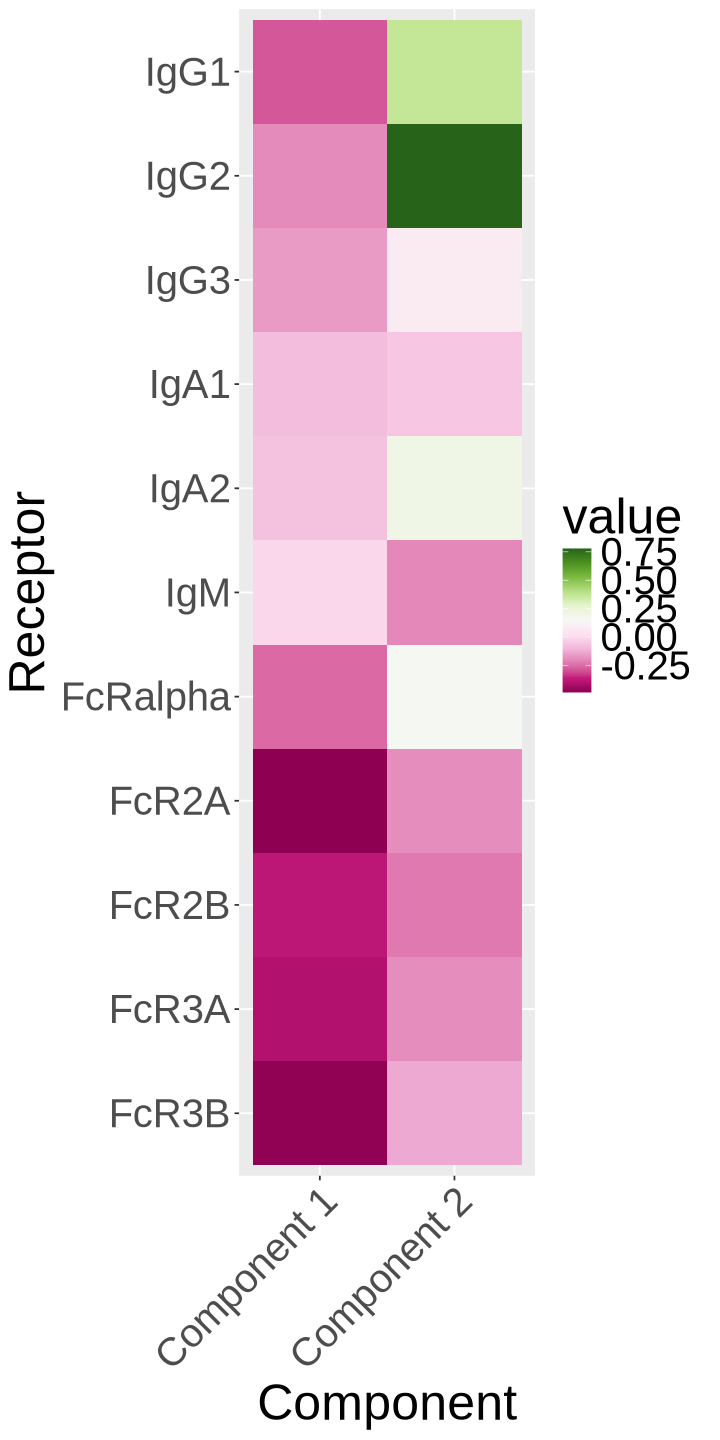

In [8]:
# 受容体パターンのヒートマップ（モード1の因子行列）
# 各受容体/抗体が2つの成分にどの程度寄与しているかを示す
#
# 元論文（CP分解）での受容体パターン (Figure 6E):
#   Component 1（急性型）: IgG3, IgM, IgA1, IgA2 + FcR系（FcR2A, FcR3A, FcR3B, FcRalpha）が高い
#     → 急性期の幅広い抗体アイソタイプとFc受容体を介した機能的免疫応答を反映
#   Component 2（長期型）: IgG1が突出して高く、他は低い
#     → クラススイッチ後の成熟した長期的抗体応答を反映
#
# HOSVDでの結果:
#   Comp1: FcR系（FcR2A, FcR2B, FcR3A, FcR3B）が突出 → 論文のComp1と部分的に一致
#     ただし論文と異なりIgG3, IgM, IgAのComp1への寄与は小さい
#   Comp2: IgG2が最も高く、次いでIgG1 → 論文の「IgG1のみ突出」とは異なる
#     直交制約のためIgG1だけに集中した成分が作れず、IgG2も混ざっている
#   全体として、FcR系 vs IgGサブクラスの分離は確認できるが、
#   論文ほど「急性型 vs 長期型」のクリーンな解釈にはならない
df_r <- prepare_pattern(res_tucker$U[[1]],
    dimnames(covid19@data)$receptor, c("Receptor"))
plot_heatmap(df_r, "Receptor")

# 抗原パターンのヒートマップ（モード2の因子行列）

各抗原（SARS-CoV-2のスパイクタンパク質やその部位）が2つの成分にどの程度寄与しているかを示す。

### 元論文との比較

元論文では抗原パターンは両成分とも比較的均一で、大きな差異はなかった (Figure 6D)。つまり急性型・長期型の違いは「どの抗原に反応するか」ではなく「どの抗体/受容体で応答するか」によって特徴づけられる。

### HOSVDでの結果

- Comp1は全抗原で比較的均一 → **論文と一致**
- Comp2ではS2とS1.Trimerが正負に大きく分かれている → これは直交制約の影響であり、論文のCP分解では見られなかったパターン

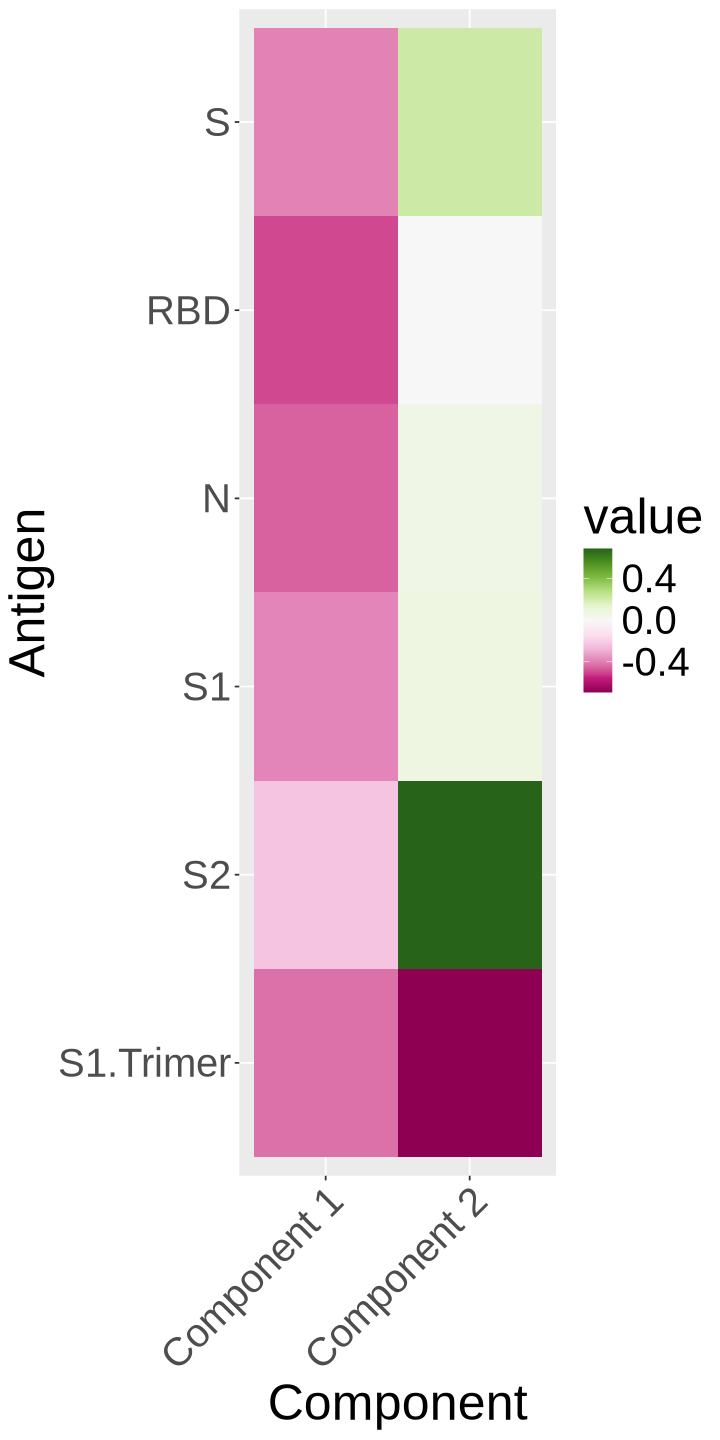

In [9]:
# 抗原パターンのヒートマップ（モード2の因子行列）
# 各抗原（SARS-CoV-2のスパイクタンパク質やその部位）が
# 2つの成分にどの程度寄与しているかを示す
#
# 元論文では抗原パターンは両成分とも比較的均一で、大きな差異はなかった (Figure 6D)
# つまり急性型・長期型の違いは「どの抗原に反応するか」ではなく
# 「どの抗体/受容体で応答するか」によって特徴づけられる
#
# HOSVDでの結果:
#   Comp1は全抗原で比較的均一 → 論文と一致
#   Comp2ではS2とS1.Trimerが正負に大きく分かれている
#   これは直交制約の影響であり、論文のCP分解では見られなかったパターン
df_a <- prepare_pattern(res_tucker$U[[2]],
    dimnames(covid19@data)$antigen, c("Antigen"))
plot_heatmap(df_a, "Antigen")

# 検体パターンのヒートマップ（モード3の因子行列、重症度グループ別）

各検体の2成分上のスコアを、重症度グループごとに並べて表示する。

- 重症度分類: **Negative**(陰性), **Mild**(軽症), **Moderate**(中等症), **Severe**(重症), **Deceased**(死亡)

### 元論文での検体パターン (Figure 6F, 6G)

- **Severe群**は両成分とも高い値を示した（強い免疫応答）
- **Deceased群**はSevere群と比べて応答が低下・遅延しており、特にComponent 1と2の両方に重みのある測定値で差が顕著だった
- **Negative群の一部**はComponent 2（IgG1）のみ陽性 → 他のコロナウイルスとの交差反応による既存免疫の可能性
- 1週目のデータだけでSevere vs Deceasedの予測AUC=0.73を達成

### HOSVDでの結果

- **Severe群のみComp2の平均が正** → 他群と異なる免疫応答パターンを持ち、**論文と整合**
- **Negative群**はComp2の分散が最も小さい → 応答が弱く均一
- **Deceased群**はComp2の分散が大きい → 応答にばらつきがあり、論文の「Deceased群は応答が低下・遅延」と整合
- ただしコアテンソルの非対角成分が大きいため、Comp1とComp2を独立に解釈することは難しく、論文のCP分解ほど明快な解釈はできない

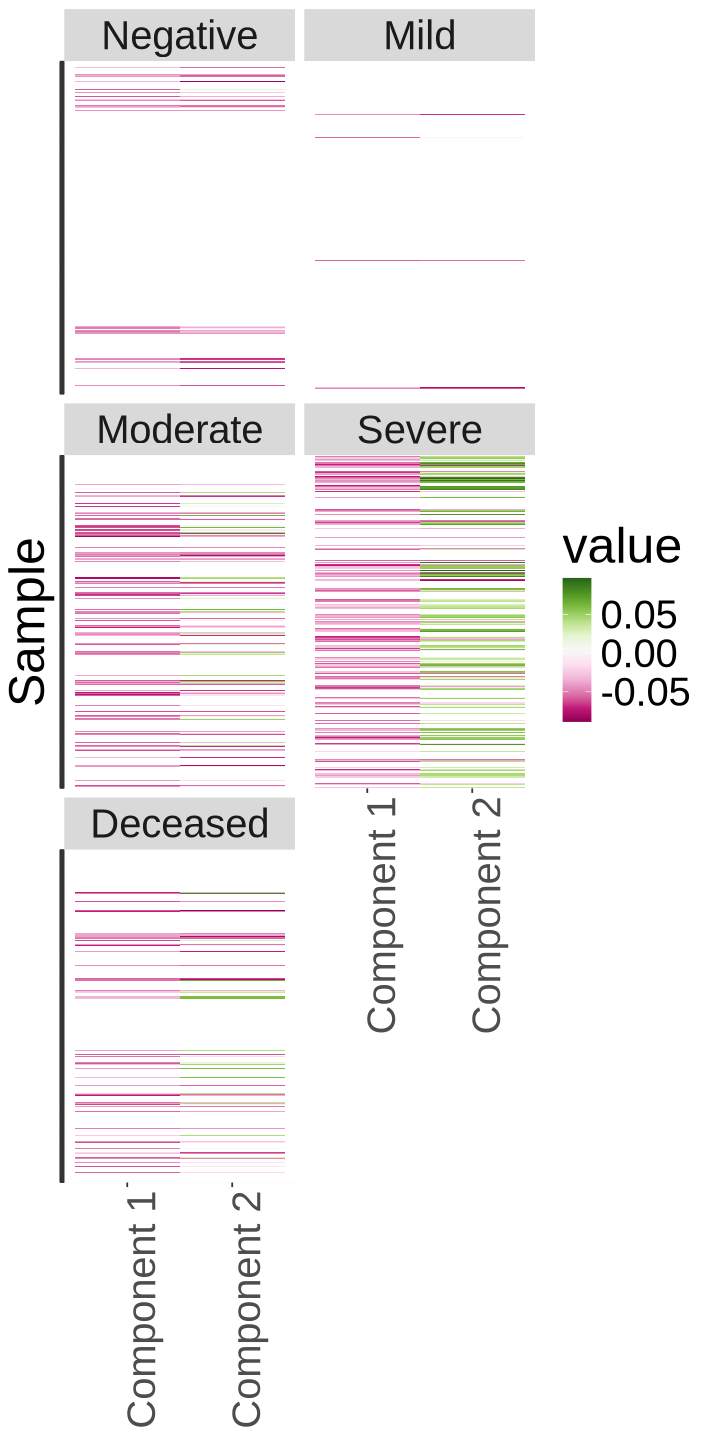

In [10]:
# 検体パターンのヒートマップ（モード3の因子行列、重症度グループ別）
# 各検体の2成分上のスコアを、重症度グループごとに並べて表示する
# 重症度分類: Negative(陰性), Mild(軽症), Moderate(中等症), Severe(重症), Deceased(死亡)
#
# 元論文での検体パターン (Figure 6F, 6G):
#   - Severe群は両成分とも高い値を示した（強い免疫応答）
#   - Deceased群はSevere群と比べて応答が低下・遅延していた
#   - Negative群の一部はComponent 2（IgG1）のみ陽性
#     → 他のコロナウイルスとの交差反応による既存免疫の可能性
#   - 1週目のデータだけでSevere vs Deceasedの予測AUC=0.73を達成
#
# HOSVDでの結果:
#   Severe群のみComp2の平均が正 → 他群と異なる免疫応答パターンを持ち、論文と整合
#   Negative群はComp2の分散が最も小さい → 応答が弱く均一
#   Deceased群はComp2の分散が大きい → 応答にばらつきがあり、
#     論文の「Deceased群は応答が低下・遅延」と整合する
#   ただしコアテンソルの非対角成分が大きいため、Comp1とComp2を
#   独立に解釈することは難しく、論文のCP分解ほど明快な解釈はできない
df_s <- prepare_pattern(res_tucker$U[[3]],
    dimnames(covid19@data)$samples, c("Sample"), group=group)
plot_heatmap(df_s, "Sample", facet_col="Group",
    extra_theme=theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        axis.title.x = element_blank(),
        axis.text.y = element_blank()))

# セッション情報

In [11]:
sessionInfo()

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 9.5 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /home/koki/miniconda3/envs/r-notebook/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Tokyo
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 reshape2_1.4.5     ggplot2_4.0.2      rTensor_1.4.9     

loaded via a namespace (and not attached):
 [1] crayon_1.5.3    vctrs_0.7.3     cli_3.6.6       rlang_1.2.0    
 [5] stringi_1.8.7   S7_0.2.1   